<a href="https://colab.research.google.com/github/shafat0/Road-for-Data-Scientist/blob/main/Visualisation_of_Weather_dataset_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Let's load the data:-
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/weather_dataset_2025.csv')
data

,Date,City,Temperature_C,Humidity_%,Wind_Speed_km_h,Precipitation_mm,Condition
0,2025-01-01,Riyadh,15.8,94,21.0,0.00,Cloudy
1,2025-01-01,Jeddah,31.5,54,25.3,3.71,Windy
2,2025-01-01,Dammam,30.4,33,8.6,3.14,Partly Cloudy
3,2025-01-01,Dubai,34.0,37,18.7,0.00,Foggy
4,2025-01-01,Doha,28.3,32,6.8,0.00,Rainy
...,...,...,...,...,...,...,...
5470,2025-12-31,Sydney,33.5,71,22.9,4.88,Sunny
5471,2025-12-31,Toronto,9.1,43,37.4,5.03,Sunny
5472,2025-12-31,Berlin,6.3,42,23.7,10.68,Windy
5473,2025-12-31,Mumbai,27.6,58,12.5,3.23,Cloudy


# 1> Let's do the visualisation of the temperature over days:-

In [ ]:
x = data['Date']
y = data['Temperature_C']

In [ ]:
x

,Date
0,2025-01-01
1,2025-01-01
2,2025-01-01
3,2025-01-01
4,2025-01-01
...,...
5470,2025-12-31
5471,2025-12-31
5472,2025-12-31
5473,2025-12-31


In [ ]:
y

,Temperature_C
0,15.8
1,31.5
2,30.4
3,34.0
4,28.3
...,...
5470,33.5
5471,9.1
5472,6.3
5473,27.6


/tmp/ipykernel_537/3146286658.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


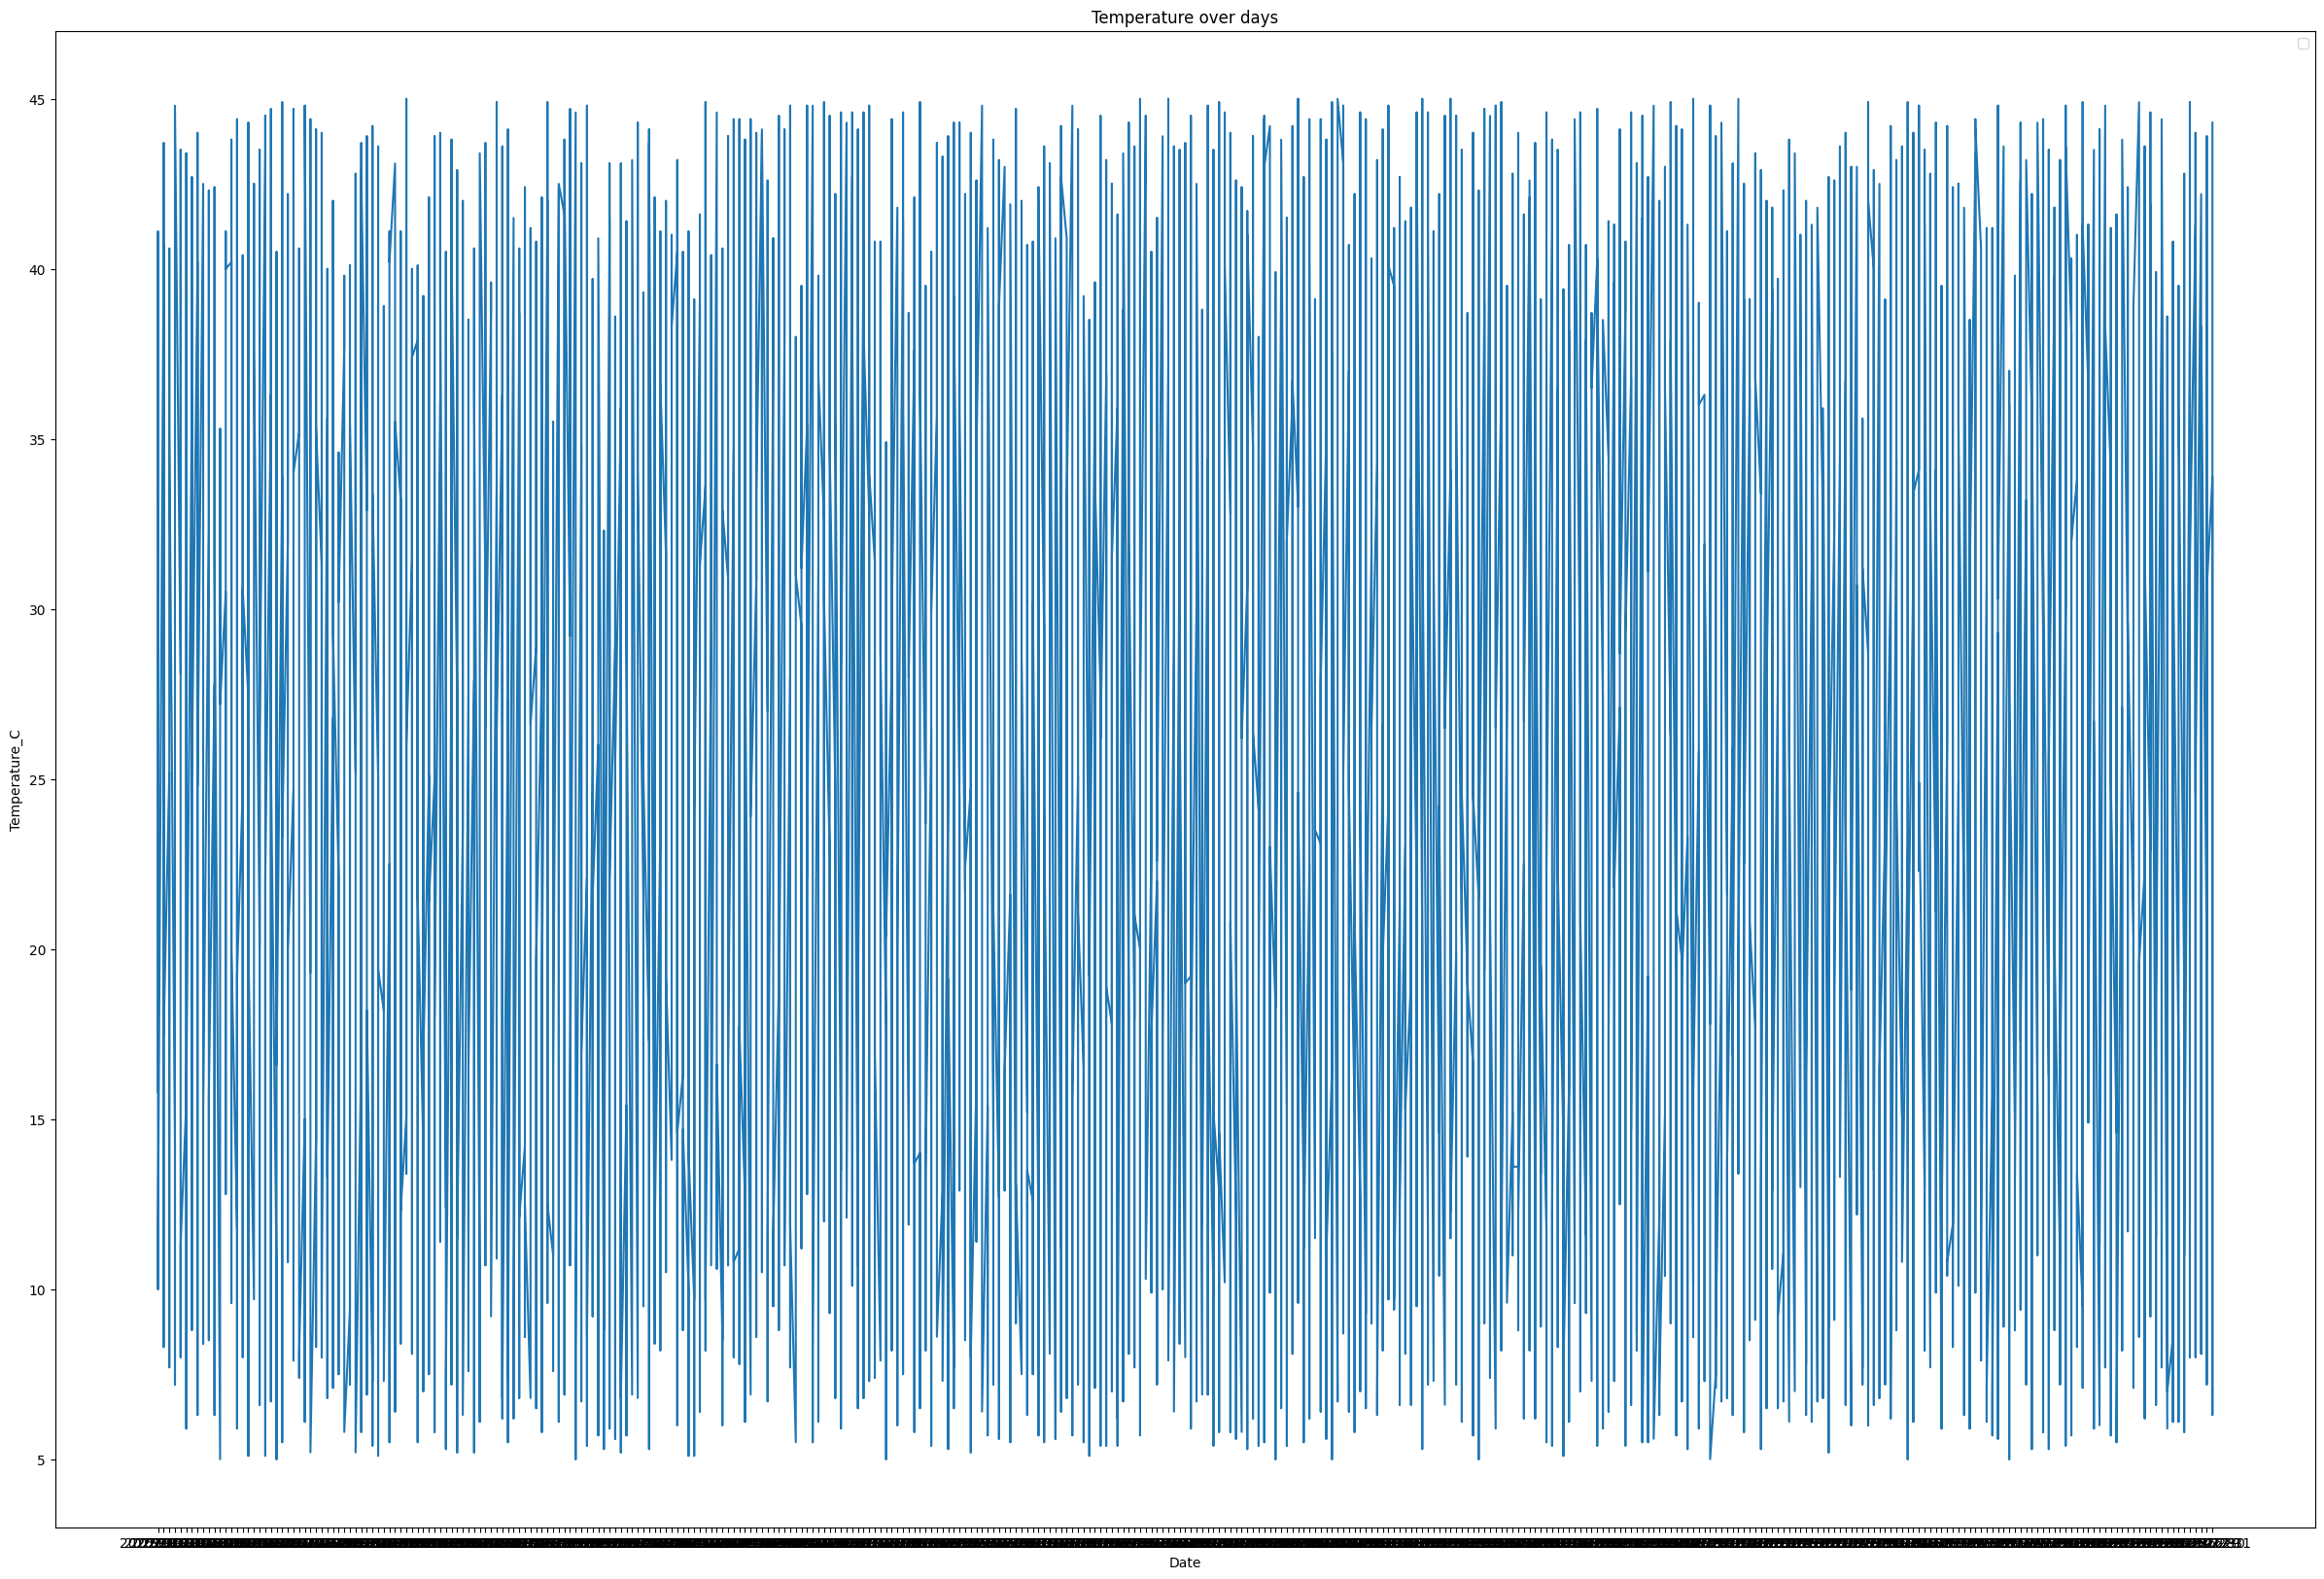

In [ ]:
plt.figure(figsize=(30,20))
plt.plot(x,y)
plt.xlabel("Date")
plt.ylabel("Temperature_C")
plt.legend()
plt.title("Temperature over days")
plt.show()

<Axes: xlabel='Date', ylabel='City'>

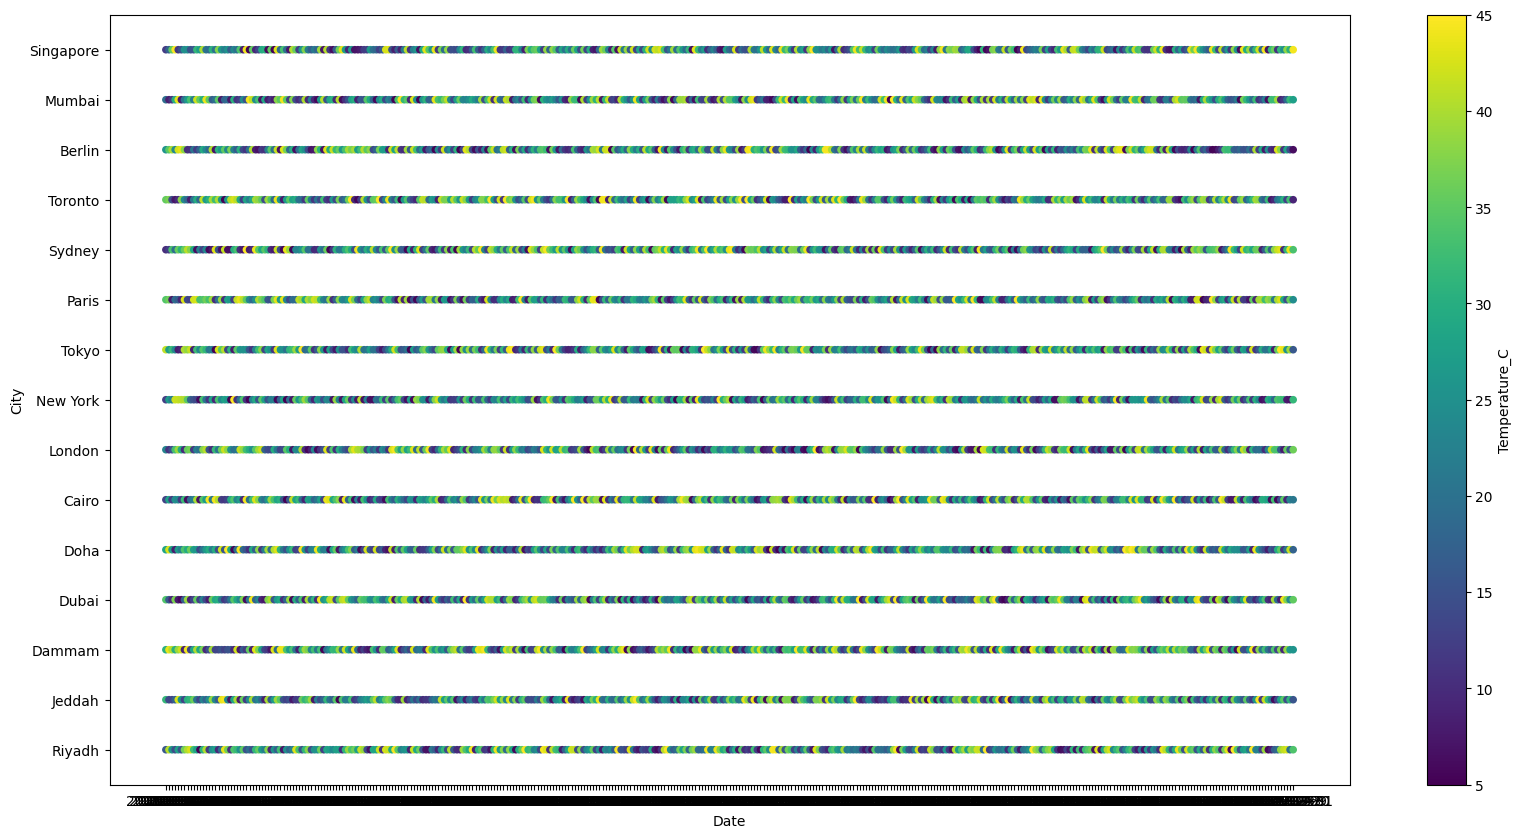

In [ ]:
fig,ax=plt.subplots(figsize=(20,10))
data.plot(kind='scatter',
          x = 'Date',
          c = 'Temperature_C',
          y = 'City',
          ax = ax)

# 2> Now let's plot the bar chart for average rainfall per month.

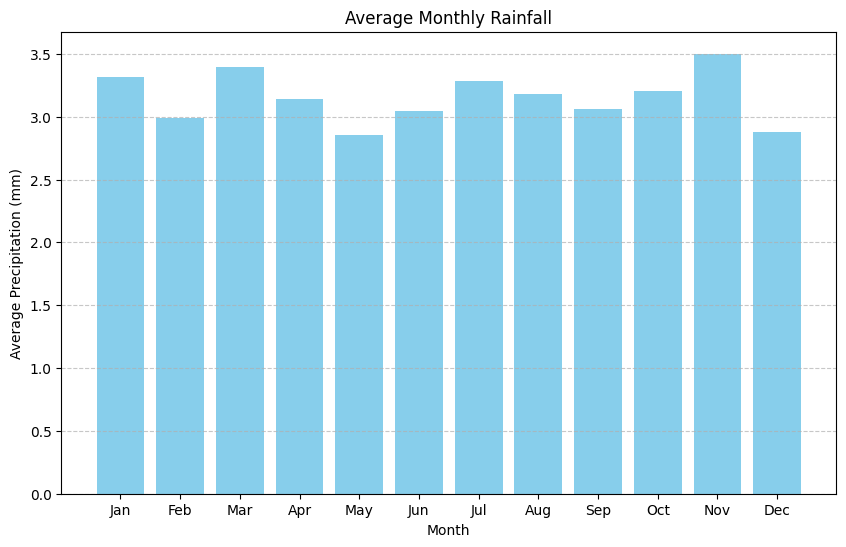

In [ ]:
# Ensure 'Date' is datetime and extract 'Month' (if not already done)
data['Date'] = pd.to_datetime(data['Date'])
data['Month'] = data['Date'].dt.month

# Calculate average monthly rainfall
monthly_avg_rainfall = data.groupby('Month')['Precipitation_mm'].mean().reset_index()

plt.figure(figsize=(10, 6))

# Define month names for better readability on the x-axis
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Create the bar plot using matplotlib.pyplot.bar
plt.bar(monthly_avg_rainfall['Month'], monthly_avg_rainfall['Precipitation_mm'], color='skyblue')

plt.title('Average Monthly Rainfall')
plt.xlabel('Month')
plt.ylabel('Average Precipitation (mm)')
plt.xticks(ticks=monthly_avg_rainfall['Month'], labels=month_names)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 3> Now make the Pie chart  for weather types:-

In [ ]:
data

,Date,City,Temperature_C,Humidity_%,Wind_Speed_km_h,Precipitation_mm,Condition,Month
0,2025-01-01,Riyadh,15.8,94,21.0,0.00,Cloudy,1
1,2025-01-01,Jeddah,31.5,54,25.3,3.71,Windy,1
2,2025-01-01,Dammam,30.4,33,8.6,3.14,Partly Cloudy,1
3,2025-01-01,Dubai,34.0,37,18.7,0.00,Foggy,1
4,2025-01-01,Doha,28.3,32,6.8,0.00,Rainy,1
...,...,...,...,...,...,...,...,...
5470,2025-12-31,Sydney,33.5,71,22.9,4.88,Sunny,12
5471,2025-12-31,Toronto,9.1,43,37.4,5.03,Sunny,12
5472,2025-12-31,Berlin,6.3,42,23.7,10.68,Windy,12
5473,2025-12-31,Mumbai,27.6,58,12.5,3.23,Cloudy,12


In [ ]:
weather_counts = data['Condition'].value_counts()
weather_counts

,count
Condition,
Stormy,813
Windy,795
Rainy,786
Foggy,785
Sunny,785
Cloudy,770
Partly Cloudy,741


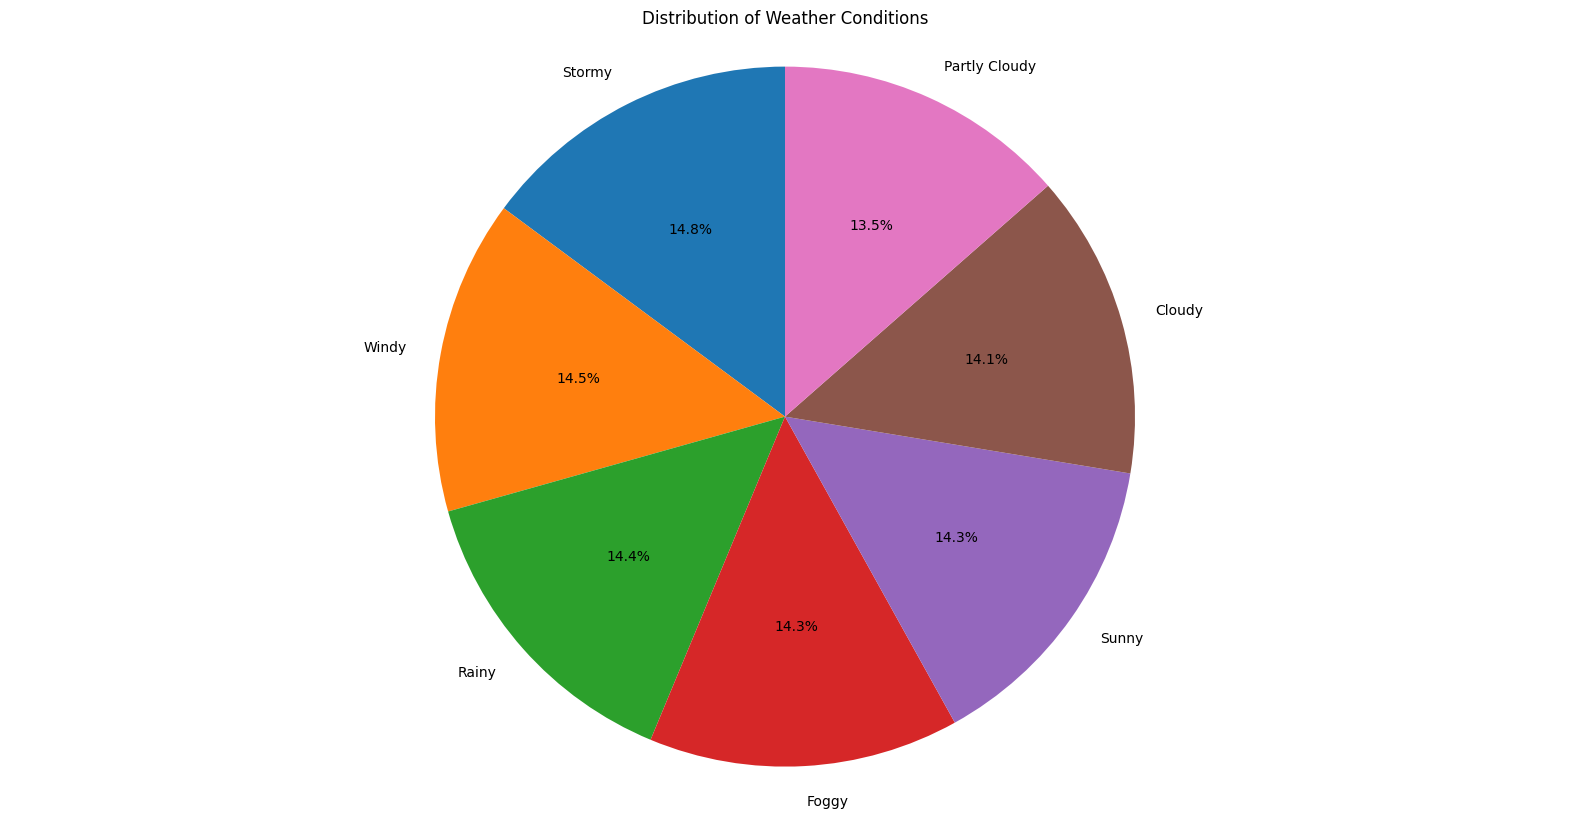

In [ ]:
plt.figure(figsize=(20,10))
plt.pie(weather_counts, labels=weather_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Weather Conditions')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()